In [1]:
# Load necessary packages

import numpy as np
import matplotlib.pyplot as plt
import yaml

from abacusnbody.hod.abacus_hod import AbacusHOD

In [2]:
# Whether to use the last computed tracer power spectra (saves time)
load_presaved = False

In [68]:
# Load the config file and parse in relevant parameters
path2config = 'config.yaml'

# Read the parameters from the yaml file
config = yaml.safe_load(open(path2config))
sim_params = config['sim_params']
HOD_params = config['HOD_params']
clustering_params = config['clustering_params']
zcv_params = config['zcv_params']

# Additional parameter choices
want_rsd = HOD_params['want_rsd']
write_to_disk = HOD_params['write_to_disk']
z_mock = sim_params['z_mock']
sim_name = sim_params['sim_name']
nmesh = zcv_params['nmesh']

In [4]:
# Run hod
newBall = AbacusHOD(sim_params, HOD_params, clustering_params)
mock_dict = newBall.run_hod(
    newBall.tracers, want_rsd, write_to_disk=write_to_disk, Nthread=16
)
nobj = mock_dict['LRG']['mass'].size
print('number of galaxies', nobj)

/users/odarwish/lenscarf/lib/python3.12/site-packages/asdf/_compression.py:46: AsdfWarning: Found more than one compressor for "blsc"
  warnings.warn(f'Found more than one compressor for "{label}"', AsdfWarning)


number of galaxies 7744344


In [69]:
# Run zcv on the power spectrum multipoles
zcv_dict = newBall.apply_zcv(mock_dict, config, load_presaved=load_presaved)
print(zcv_dict.keys())

D =  58.8985672746677
min/max tracer pos 0.0 1999.9999 (7744344, 3)
Computing auto-correlation of tracer
Computing cross-correlation of tracer and  delta
Computing cross-correlation of tracer and  delta2
Computing cross-correlation of tracer and  tidal2


AssertionError: Requested keynames should follow the standard order

In [ ]:
zcv_dict['bias']

In [6]:
#full bias vector, corresponding to b1, b2, bs, bn, shotnoise
zcv_dict['bias']

array([ 0.36689901,  1.56643374, -1.6516653 ,  0.        ,  0.00521988])

In [7]:
for key in zcv_dict.keys():
    if 'Pk' in key:
        print(key, zcv_dict[key][:10])
        print('-----------------')

Pk_ZD_ZD_ell [1.02245960e+16 1.09080935e+04 2.35651453e+04 2.26763203e+04
 2.73708170e+04 2.52434032e+04 2.45014509e+04 2.61587023e+04
 2.19788002e+04 2.01826078e+04]
-----------------
Pk_tr_ZD_ell [-63695.32403679  10555.98665159  23706.40827238  22042.85017712
  26088.18384897  24467.05669838  23953.4476481   25654.7830457
  21092.23099157  19595.90299066]
-----------------
Pk_tr_tr_ell [10622.95410156 10727.69433594 24823.51953125 22313.56054688
 25756.5703125  24621.70117188 24465.24023438 26105.88476562
 21291.35351562 20181.48828125]
-----------------
Pk_tr_tr_ell_zcv [[-1.02028555e+16  1.50772715e+04  2.21623853e+04  2.37876343e+04
   2.40528864e+04  2.53149066e+04  2.52844808e+04  2.40598730e+04
   2.19145583e+04  2.09464178e+04  1.92662734e+04  1.79720698e+04
   1.62605514e+04  1.55746800e+04  1.43951235e+04  1.36265485e+04
   1.30794176e+04  1.25215921e+04  1.22188530e+04  1.16767981e+04
   1.14194796e+04  1.11765282e+04  1.05115794e+04  1.03135172e+04
   9.73979576e+03  9.23

In [8]:
zcv_dict[key].shape

(5,)

In [9]:
# Parse the output from the ZCV-reduced power spectrum measurements
k_binc = zcv_dict['k_binc']
pk_nn_betasmooth = zcv_dict['Pk_tr_tr_ell_zcv']
pk_tt_poles = zcv_dict['Pk_tr_tr_ell']
pk_zz = zcv_dict['Pk_ZD_ZD_ell']
pk_zn = zcv_dict['Pk_tr_ZD_ell']
r_zt = zcv_dict['rho_tr_ZD']
pk_zenbu = zcv_dict['Pk_ZD_ZD_ell_ZeNBu']

In [10]:
from classy import Class

from abacusnbody.metadata import get_meta
sim_name = "AbacusSummit_base_c000_ph000"
z_this = 0.5
meta = get_meta(sim_name, redshift=z_this)

boltz = Class()
cosmo = {}
cosmo['output'] = 'mPk mTk'
cosmo['P_k_max_h/Mpc'] = 20.0
cosmo['non linear'] = 'halofit'
cosmo['z_pk'] = '0.0, 0.2, 0.5, 1.0, 2.0'
int(sim_name.split('ph')[-1])
for k in (
        'H0',
        'omega_b',
        'omega_cdm',
        'omega_ncdm',
        'N_ncdm',
        'N_ur',
        'n_s',
        'A_s',
        'alpha_s',
        #'wa', 'w0',
):
    cosmo[k] = meta[k]
boltz.set(cosmo)
boltz.compute()

In [11]:
#comparing to pyccl
import pyccl as ccl

import pyccl as ccl
import pyccl.nl_pt as pt

h = cosmo['H0']/100
cosmopy = ccl.Cosmology(Omega_c=cosmo['omega_cdm']/h**2, Omega_b=cosmo['omega_b']/h**2, h=h, 
                        A_s=cosmo['A_s'], n_s=cosmo['n_s'], m_nu = 0.06)

In [12]:
#full bias vector, corresponding to b1, b2, bs, bn, shotnoise
zcv_dict['bias']

array([ 0.36689901,  1.56643374, -1.6516653 ,  0.        ,  0.00521988])

In [67]:


b_1 = zcv_dict['bias'][0]
b_2 = zcv_dict['bias'][1]
b_s = zcv_dict['bias'][2]
b_delta = zcv_dict['bias'][3]
b_shot = zcv_dict['bias'][4]

ptt_g = pt.PTNumberCountsTracer(b1=b_1, b2=b_2, bs=b_s)

ptc = pt.EulerianPTCalculator(with_NC=True, with_IA=False,
                      log10k_min=-4, log10k_max=2, nk_per_decade=20)
ptc.update_ingredients(cosmopy)
pk_gg = ptc.get_biased_pk2d(ptt_g)

ptt_m = pt.PTMatterTracer()
pk_mm = ptc.get_biased_pk2d(ptt_m, tracer2=ptt_m)
pk_gm = ptc.get_biased_pk2d(ptt_g, tracer2=ptt_m)

kk = k_binc

z = 0.5
ks = kk*h**1
ps = {}
a = 1/(1+z)
pgg = pk_gg(ks, a, cosmopy)
pmm = pk_mm(ks, a, cosmopy)

pgg *= h**3
pmm *= h**3
ks *= h**-1.

0.6666666666666666

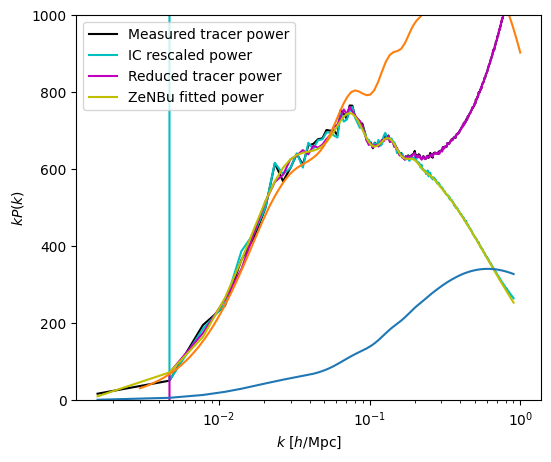

In [66]:
# Set up the canvas
cs = ['k', 'c', 'm', 'y']
if want_rsd:
    figsize = (12, 5)
    n_ell = 3
else:
    figsize = (6, 5)
    n_ell = 1
f, ax = plt.subplots(1, n_ell, sharex=True, sharey=True, figsize=figsize)
if not want_rsd:
    ax = [ax]

# Loop over all multipoles
for ell in range(n_ell):
    if want_rsd:
        pk_zz_ell = pk_zz[ell, :].flatten()
        pk_zenbu_ell = pk_zenbu[ell, :].flatten()
        pk_tt_poles_ell = pk_tt_poles[ell, :]
        pk_nn_betasmooth_ell = pk_nn_betasmooth[ell, :]
    else:
        pk_zz_ell = pk_zz.flatten()
        pk_zenbu_ell = pk_zenbu.flatten()
        pk_tt_poles_ell = pk_tt_poles.flatten()
        pk_nn_betasmooth_ell = pk_nn_betasmooth.flatten()

    ax[ell].plot(
        k_binc, k_binc * pk_tt_poles_ell, c=cs[0], label='Measured tracer power'
    )
    ax[ell].plot(k_binc, k_binc * pk_zz_ell, c=cs[1], label='IC rescaled power')
    ax[ell].plot(
        k_binc, k_binc * pk_nn_betasmooth_ell, c=cs[2], label='Reduced tracer power'
    )
    ax[ell].plot(k_binc, k_binc * pk_zenbu_ell, c=cs[3], label='ZeNBu fitted power')

    if ell == 0:
        ax[ell].set_ylabel(r'$k P(k)$')
    ax[ell].set_xlabel(r'$k \ [h/{\rm Mpc}]$')

plt.plot(k_binc, k_binc * pgg)   


plt.plot(k_, k_*p_)

plt.ylim(0, 1000)
plt.xscale('log')
plt.legend()

In [58]:
from ZeNBu.zenbu import Zenbu
k, p = np.loadtxt("/users/odarwish/ZeNBu/ZeNBu/Pk_Planck15_Table4.txt", unpack=True)
zen  = Zenbu(k, 0.5*p, jn = 15)
zen.make_ptable(kmin=3e-3, kmax = 1.0)

# Let's explicitly list the components
# Note that the cross spectra are multiplied by a factor of one half.

kv = zen.pktable[:,0]

spectra = {\
          r'$(1,1)$':zen.pktable[:,1],\
          r'$(1,b_1)$':zen.pktable[:,2], r'$(b_1,b_1)$': zen.pktable[:,3],\
          r'$(1,b_2)$':zen.pktable[:,4], r'$(b_1,b_2)$': zen.pktable[:,5],  r'$(b_2,b_2)$': zen.pktable[:,6],\
          r'$(1,b_s)$':zen.pktable[:,7], r'$(b_1,b_s)$': zen.pktable[:,8],  r'$(b_2,b_s)$': zen.pktable[:,9], r'$(b_s,b_s)$':zen.pktable[:,10],\
          }

k_, p_ = zen.combine_bias_terms_pk(b_1, b_2, b_s, 0, 0, 0)

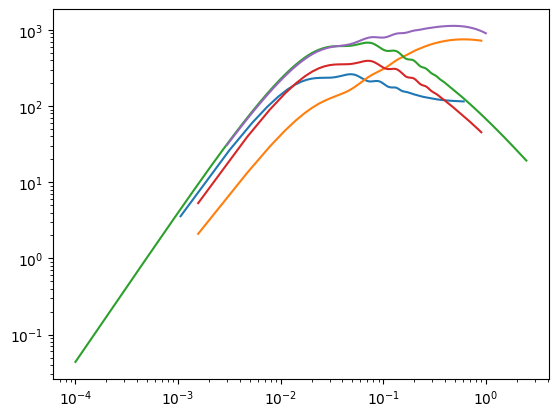

In [65]:

kk = k_binc*h
mm = pmm#/h**3
plt.loglog(kk, kk*mm)   
plt.loglog(k_binc,  k_binc*pgg/h**2)   
plt.plot(k, k*p)

pk_nl = np.array([ccl.linear_matter_power(cosmopy, k_i, 1/(1+z)) for k_i in kk])
plt.loglog(k_binc, k_binc*pk_nl*h**3)

plt.plot(k_, k_*p_)
